In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'


import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from matplotlib import gridspec
import matplotlib.path as mpath
from matplotlib import ticker, cm
import numpy as np
import netCDF4 as nc
import xarray as xr
import cmocean.cm as cmocean

import glob,os
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as mticker

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

import gsw
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import intake 
import dask.distributed as dask
from dask.distributed import Client
import cmcrameri
figdir = '/g/data/x77/ps7863/figures/AABW_variability/'
degree = u'\N{DEGREE SIGN}'

import sys
sys.path.append("/g/data/x77/ps7863/python_scripts/AABW_variability/")
import helper_funcs as helper

In [2]:
from os import environ
environ["PYTHONWARNINGS"] = "ignore"

In [3]:
client = Client(threads_per_worker=1,memory_limit=0)
client.amm.start()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39835 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/39835/status,
Dashboard: /proxy/39835/status,Workers: 12
Total threads: 12,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36825,Workers: 0
Dashboard: /proxy/39835/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33301,Total threads: 1
Dashboard: /proxy/33927/status,Memory: 0 B
Nanny: tcp://127.0.0.1:41433,


2026-04-25 22:27:35,360 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('rechunk-split-7b59b47c44c75722d00e7da103dda87d', 34) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: <Task ('rechunk-split-7b59b47c44c75722d00e7da103dda87d', 34) getitem(...)>
new run_spec: Alias(('rechunk-split-7b59b47c44c75722d00e7da103dda87d', 34)->('open_dataset-temp-rechunk-split-7b59b47c44c75722d00e7da103dda87d', 34))
old dependencies: {('open_dataset-temp-a57e2d2f81366e5cf659cac93bdfc501', 10, 0, 2)}
new dependencies: frozenset({('open_dataset-temp-rechunk-split-7b59b47c44c75722d00e7da103dda87d', 34)})

2026-04-25 22:2

In [4]:
iaf_cycle3 = '01deg_jra55v140_iaf_cycle3'
expt = '01deg_jra55v140_iaf_cycle3_antarctic_tracers'
catalog = intake.cat.access_nri

In [5]:
# lon_slice = slice(-70, 80)
lat_slice = slice(-82, -55)

degree =  u'\N{DEGREE SIGN}'

In [6]:
def yearly_mean(var):
    month_length = var.time.dt.days_in_month
    weights_month = (month_length.groupby('time.year') /
                     month_length.groupby('time.year').sum())
    var = (var * weights_month).groupby('time.year').sum()
    var = var.rename({'year': 'time'})
    return var

## Load necessary model variables

``ht`` for bathymetry contours

In [7]:
chunks_dict = {
    'time' : 36,
    'st_ocean' : 75,
    'yu_ocean' : '250Mb',
    'xu_ocean' : 360,
}

In [8]:
var='ht'
ht = catalog[iaf_cycle3].search(
    variable=var
).to_dask(
    threaded=False,
    xarray_open_kwargs = {            
    "decode_timedelta" : True}
)
ht = ht['ht']


ht = ht.sel(yt_ocean=lat_slice)
land_mask = np.squeeze(ht.values)
land_mask = land_mask * 0
land_mask[np.isnan(land_mask)] = 1
yt_ocean =ht.yt_ocean.values
xt_ocean =ht.xt_ocean.values
land_mask_masked = np.ma.masked_where((land_mask==0),land_mask)

land = xr.where(np.isnan(ht.rename('land')), 1, np.nan)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


In [9]:
ht_rewrap = (helper.wrap_centered(ht, center=-30))


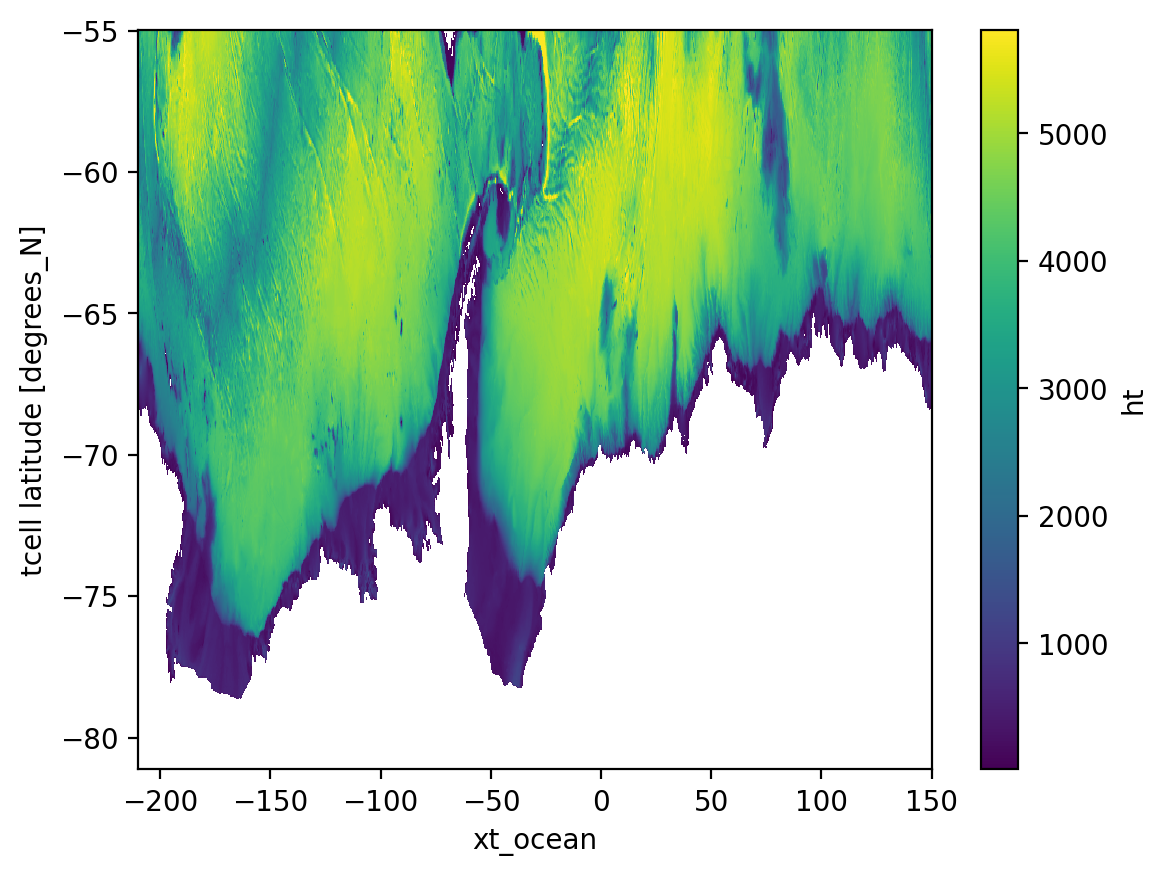

In [43]:
ht_rewrap.plot()

In [10]:
shelf_mask = ht > 1000
shelf_mask = shelf_mask.astype(bool)
masked_shelf = shelf_mask.where(shelf_mask==0, np.nan)
shelf_mask = shelf_mask.where(shelf_mask==1, np.nan)
shelf_mask

<xarray.DataArray 'ht' (yt_ocean: 584, xt_ocean: 3600)> Size: 17MB
dask.array<where, shape=(584, 3600), dtype=float64, chunksize=(540, 720), chunktype=numpy.ndarray>
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 5kB -81.11 -81.07 -81.02 ... -55.07 -55.01

In [11]:
ht=ht.chunk({'xt_ocean': 360, 'yt_ocean': '200Mb'})
ht

<xarray.DataArray 'ht' (yt_ocean: 584, xt_ocean: 3600)> Size: 8MB
dask.array<rechunk-merge, shape=(584, 3600), dtype=float32, chunksize=(584, 360), chunktype=numpy.ndarray>
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 5kB -81.11 -81.07 -81.02 ... -55.07 -55.01
Attributes:
    long_name:      ocean depth on t-cells
    units:          m
    valid_range:    [-1.e+09  1.e+09]
    cell_methods:   time: point
    standard_name:  sea_floor_depth_below_geoid

## Load pre-saved model T, S

In [12]:
bottom_temp = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_tracers/bottom_temp_1958-2018.nc', 
                      chunks={'time':12, 'yt_ocean': '250Mb', 'xt_ocean': 360})
# convert to dataarray 
bottom_temp = bottom_temp['temp']


In [13]:
bottom_temp = bottom_temp.chunk({'time':'125Mb', 'yt_ocean': 584, 'xt_ocean': 360})

In [14]:
# calculate climatology and climatological seasonal range + seasonal range for each year

temp_clim = bottom_temp.groupby('time.month').mean('time')
temp_range = temp_clim.max('month') - temp_clim.min('month')
temp_range_yearly = bottom_temp.groupby('time.year').max('time') - bottom_temp.groupby('time.year').min('time')



# Weddell moorings 

In [20]:
files = [
    # '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_1989_deepest.nc', 
    # '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_1990_deepest.nc',
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_1993_deepest.nc',
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_1996_deepest.nc', 
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_2005_deepest.nc',
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_2008_deepest.nc',
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_2011_deepest.nc',
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_2013_deepest.nc', 
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI207_2017_deepest.nc'
]

arrays = [xr.open_dataset(x) for x in files]


In [21]:
arrays_CT = [ds.CT.resample(time='1D').mean('time') for ds in arrays]
arrays_salt = [ds.salinity.resample(time='1D').mean('time') for ds in arrays]
arrays_temp = [ds.temperature.resample(time='1D').mean('time') for ds in arrays]
arrays_pres = [ds.pressure.resample(time='1D').mean('time') for ds in arrays]

In [22]:
def merge_mooring_dataarrays(
    arrays,
    time_name="time",
    freq=None,
    overlap_reducer="median",   # 'median' | 'mean' | 'first' | 'last'
    assume_sorted=False,
):
    """
    Merge multiple DataArrays from the same location into a single continuous series.
    - arrays: list of xr.DataArray, each with a time coordinate.
    - freq: optional pandas offset alias (e.g., '5min', '1H'). If None, inferred.
    - overlap_reducer: how to combine duplicate timestamps after concat.
    """
    # 1) Concatenate along time (outer coords okay)
    da = xr.concat(arrays, dim=time_name, data_vars="all", coords="all", join="outer")

    # 2) Sort by time if needed
    if not assume_sorted:
        da = da.sortby(time_name)

    # 3) Collapse duplicates within overlaps
    if da.indexes is not None and time_name in da.indexes:
        # groupby exact timestamps and reduce
        if overlap_reducer in ("median", "mean"):
            func = getattr(xr.core.dataarray.DataArray, overlap_reducer)
            da = da.groupby(time_name).apply(func)
        elif overlap_reducer == "first":
            da = da.groupby(time_name).first()
        elif overlap_reducer == "last":
            da = da.groupby(time_name).last()
        else:
            raise ValueError("overlap_reducer must be one of 'median','mean','first','last'")

    # 4) If you want explicit NaNs in gaps, reindex to a regular grid
    # if freq is None:
    #     tindex = da.indexes[time_name]
    #     freq = _infer_freq_from_timeindex(tindex)

    full_time = pd.date_range(da[time_name].min().item(), da[time_name].max().item(), freq=freq)
    da_full = da.reindex({time_name: full_time})  # inserts NaNs for missing stamps

    return da_full


In [23]:
# Suppose you’ve already read each file and extracted a DataArray with .name = 'temperature'
# and a proper 'time' coordinate:
# da1, da2, da3 = ...

merged_temp = merge_mooring_dataarrays(arrays_temp, time_name="time", overlap_reducer="median", freq='1d')
# Now merged is a single DataArray with NaNs where redeployments had gaps.
merged_salt = merge_mooring_dataarrays(arrays_salt, time_name='time', overlap_reducer='median', freq='1d')

merged_pres = merge_mooring_dataarrays(arrays_pres, time_name='time', overlap_reducer='median')

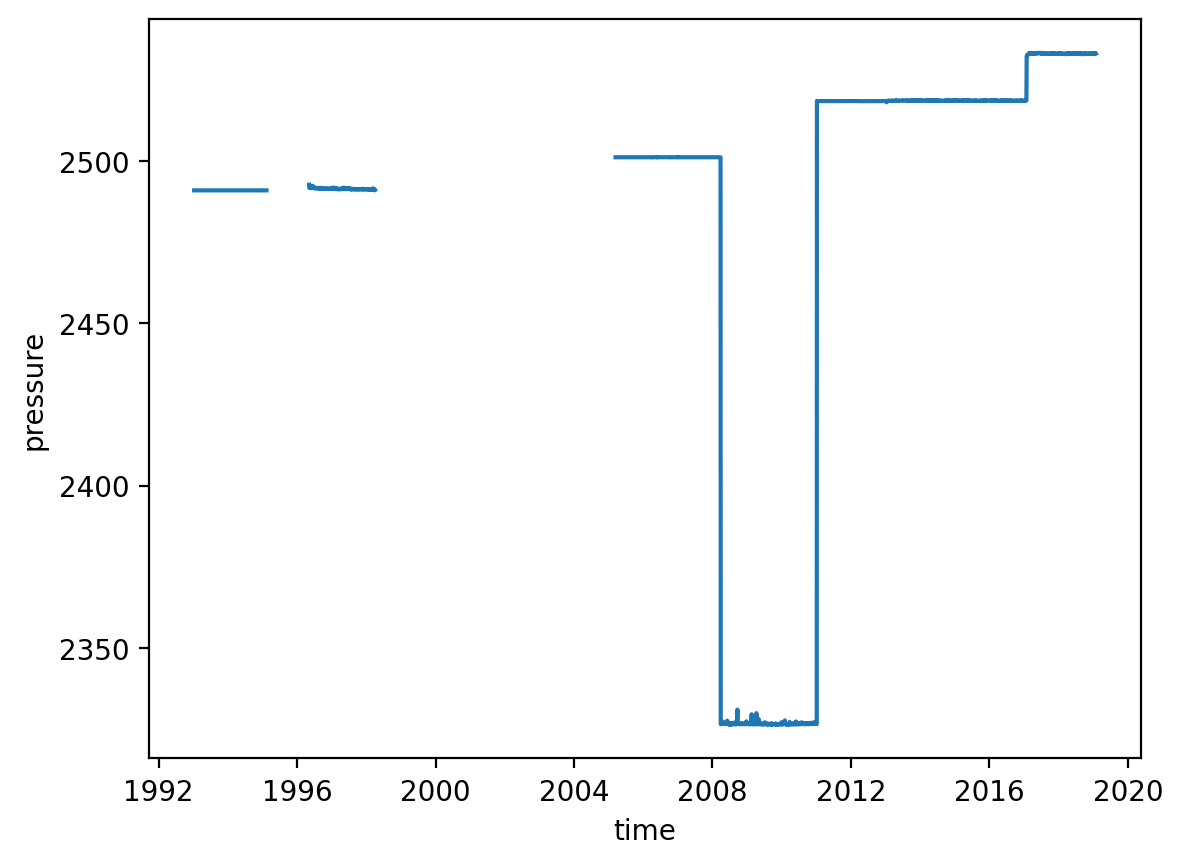

In [44]:
merged_pres.plot()

In [17]:
files = [
    # '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI217_1990_deepest.nc', 
    # '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI217_1993_deepest.nc', 
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI217_2008_deepest.nc',
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI217_2011_deepest.nc', 
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI217_2013_deepest.nc'
]

arrays = [xr.open_dataset(x) for x in files]
CT = [ds.CT.resample(time='1D').mean('time') for ds in arrays]
salt = [ds.salinity.resample(time='1D').mean('time') for ds in arrays]
temp = [ds.temperature.resample(time='1D').mean('time') for ds in arrays]
pres = [ds.pressure.resample(time='1D').mean('time') for ds in arrays]
awi_lon =  [ds.lon.item() for ds in arrays]
awi_lat = [ds.lat.item() for ds in arrays]

In [18]:
awi217_merged_CT = merge_mooring_dataarrays(CT, time_name="time", overlap_reducer="median", freq='1d')
# Now merged is a single DataArray with NaNs where redeployments had gaps.
awi217_merged_salt = merge_mooring_dataarrays(salt, time_name='time', overlap_reducer='median', freq='1d')
awi217_merged_pres = merge_mooring_dataarrays(pres, time_name='time', overlap_reducer='median', freq='1d')

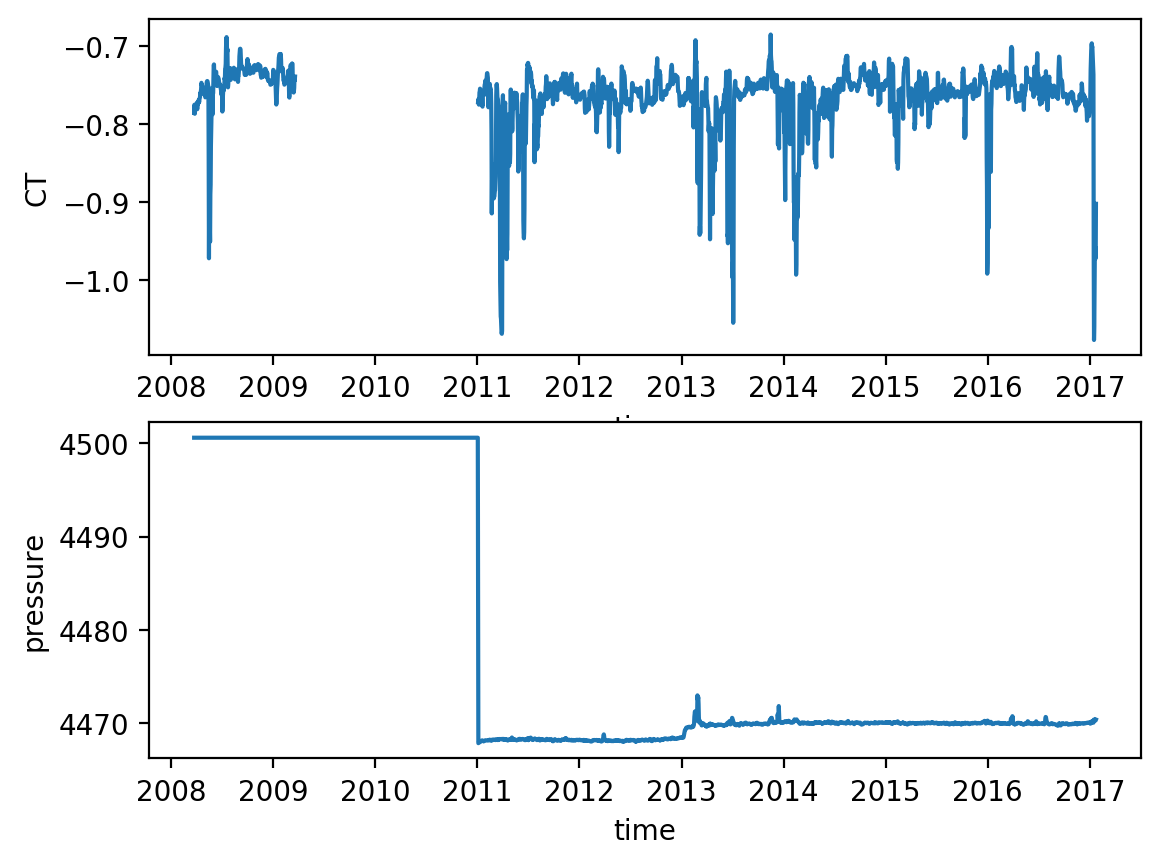

In [19]:
fig, ax = plt.subplots(2,1)
awi217_merged_CT.plot(ax=ax[0])
awi217_merged_pres.plot(ax=ax[1])

In [24]:
ross_moorings = [
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/CALM_ca207_deepest.nc', 
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/CALM_ca208_deepest.nc'
]

arrays = [xr.open_dataset(x) for x in ross_moorings]
CT = [ds.CT.resample(time='1D').mean('time') for ds in arrays]
salt = [ds.salinity.resample(time='1D').mean('time') for ds in arrays]
temp = [ds.temperature.resample(time='1D').mean('time') for ds in arrays]
calm_lon = [ds.lon.item() for ds in arrays]
calm_lat = [ds.lat.item() for ds in arrays]
CALM_merged_CT = merge_mooring_dataarrays(CT, time_name="time", overlap_reducer="median", freq='1d')


In [25]:
adelie_moorings = [
    '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/Mertz98_polynya_2_deepest.nc', 
    # '/g/data/x77/ps7863/data/AABW_variability/moorings/processed/Mertz98_polynya_1_deepest.nc'
]

arrays = [xr.open_dataset(x) for x in adelie_moorings]
CT = [ds.CT.resample(time='1D').mean('time') for ds in arrays]
salt = [ds.salinity.resample(time='1D').mean('time') for ds in arrays]
temp = [ds.temperature.resample(time='1D').mean('time') for ds in arrays]
mertz_lon =  [ds.lon.item() for ds in arrays]
mertz_lat = [ds.lat.item() for ds in arrays]
Mertz_merged_CT = merge_mooring_dataarrays(CT, time_name="time", overlap_reducer="median", freq='1d')


## Open mooring files for each region 

In [38]:
mertz2 = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/moorings/processed/Mertz98_polynya_2_deepest.nc')

# calm1 = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/moorings/processed/CALM_ca108_instr2_processed.nc')
# calm2 = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/moorings/processed/CALM_ca108_instr5_processed.nc')
kombi = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/obs/KOMBI_2_filtered.nc')

# awi217 = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/moorings/processed/AWI217_2008_processed.nc')
# calculate climatology and seasonal range (+ seasonal range for each year, for moorings > 1 year )
# monthly climatology 
mertz2_clim = mertz2.groupby('time.month').mean('time')
# calm1_clim = calm1.groupby('time.month').mean('time') 
# calm2_clim = calm2.groupby('time.month').mean('time') 
kombi_clim = kombi.groupby('time.month').mean('time')
awi217_clim = awi217_merged_CT.groupby('time.month').mean('time')
calm_clim = CALM_merged_CT.groupby('time.month').mean('time')
# mertz_clim = mertz1.CT.groupby('time.month').mean('time')

# seasonal range 
# mertz2_range = mertz2_clim.max('month') - mertz2_clim.min('month')
# calm1_range = calm1_clim.max('month') - calm1_clim.min('month')
# calm2_range = calm2_clim.max('month') - calm2_clim.min('month') 
kombi_range = kombi_clim.max('month') - kombi_clim.min('month') 
awi217_range = awi217_clim.max('month') - awi217_clim.min('month')
calm_range = calm_clim.max('month') - calm_clim.min('month')
mertz_range = mertz2_clim.max('month') - mertz2_clim.min('month')
# annual seasonal range 

# since data is hourly, we need to resample it to monthly time steps before calculating seasonal range in year-groups 
# calm1_monthly = calm1.resample(time='1M').mean('time')
# calm2_monthly = calm2.resample(time='1M').mean('time')
# calm1_range_annual = calm1_monthly.resample(time='AS-FEB').max('time') -  calm1_monthly.resample(time='AS-FEB').min('time') 
# calm2_range_annual = calm2_monthly.resample(time='AS-FEB').max('time') -  calm2_monthly.resample(time='AS-FEB').min('time') 
calm_monthly = CALM_merged_CT.resample(time='1M').mean('time')
calm_range_annual = calm_monthly.resample(time='AS-FEB').max('time') - calm_monthly.resample(time='AS-FEB').min('time')

kombi_monthly = kombi.resample(time='1M').mean('time')
kombi_range_annual = kombi_monthly.resample(time='AS-FEB').max('time') - kombi_monthly.resample(time='AS-FEB').min('time')

awi217_monthly = awi217_merged_CT.resample(time='1M').mean('time') 
awi217_range_annual = awi217_monthly.resample(time='YS-MAR').max('time') - awi217_monthly.resample(time='YS-MAR').min('time')


mertz_monthly = mertz2.resample(time='1M').mean('time')
mertz_range_annual = mertz_monthly.max('time') - mertz_monthly.min('time')


# monthly max & min (range)
mertz2_clim_max = mertz2.groupby('time.month').max('time')
kombi_clim_max=  kombi.groupby('time.month').max('time')
awi217_clim_max= awi217_merged_CT.groupby('time.month').max('time')
calm_clim_max = CALM_merged_CT.groupby('time.month').max('time')

mertz2_clim_min = mertz2.groupby('time.month').min('time')
kombi_clim_min =  kombi.groupby('time.month').min('time')
awi217_clim_min = awi217_merged_CT.groupby('time.month').min('time')
calm_clim_min = CALM_merged_CT.groupby('time.month').min('time')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/groupers.py:513: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/groupers.py:513: FutureWarning: 'AS-FEB' is deprecated and will be removed in a future version, please use 'YS-FEB' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/groupers.py:513: FutureWarning: 'AS-FEB' is deprecated and will be removed in a future version, please use 'YS-FEB' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/xarray/groupers.py:513: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/g/data/xp

In [55]:
mertz2_clim


<xarray.Dataset> Size: 592B
Dimensions:      (month: 12)
Coordinates:
    lon          float64 8B ...
    lat          float64 8B ...
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    temperature  (month) float64 96B -0.3775 -0.3881 -0.522 ... -0.4446 -0.4495
    salinity     (month) float64 96B 34.63 34.62 34.6 34.6 ... 34.63 34.64 34.64
    pressure     (month) float64 96B 1.172e+03 1.172e+03 ... 1.172e+03 1.172e+03
    SA           (month) float64 96B 34.8 34.79 34.77 34.77 ... 34.8 34.81 34.81
    CT           (month) float64 96B -0.4249 -0.4353 -0.5677 ... -0.4914 -0.4962
Attributes:
    Description:        Data from mooring Mertz98_polynya_2, deepest instrume...
    bottom_depth:       1180.0
    lon:                142.9159
    lat:                -65.8011
    start_date:         1998-04-16
    end_date:           1999-05-15
    source_file:        Mertz98_polynya_2.nc
    instrument_choice:  deepest
    instrument_id:      5

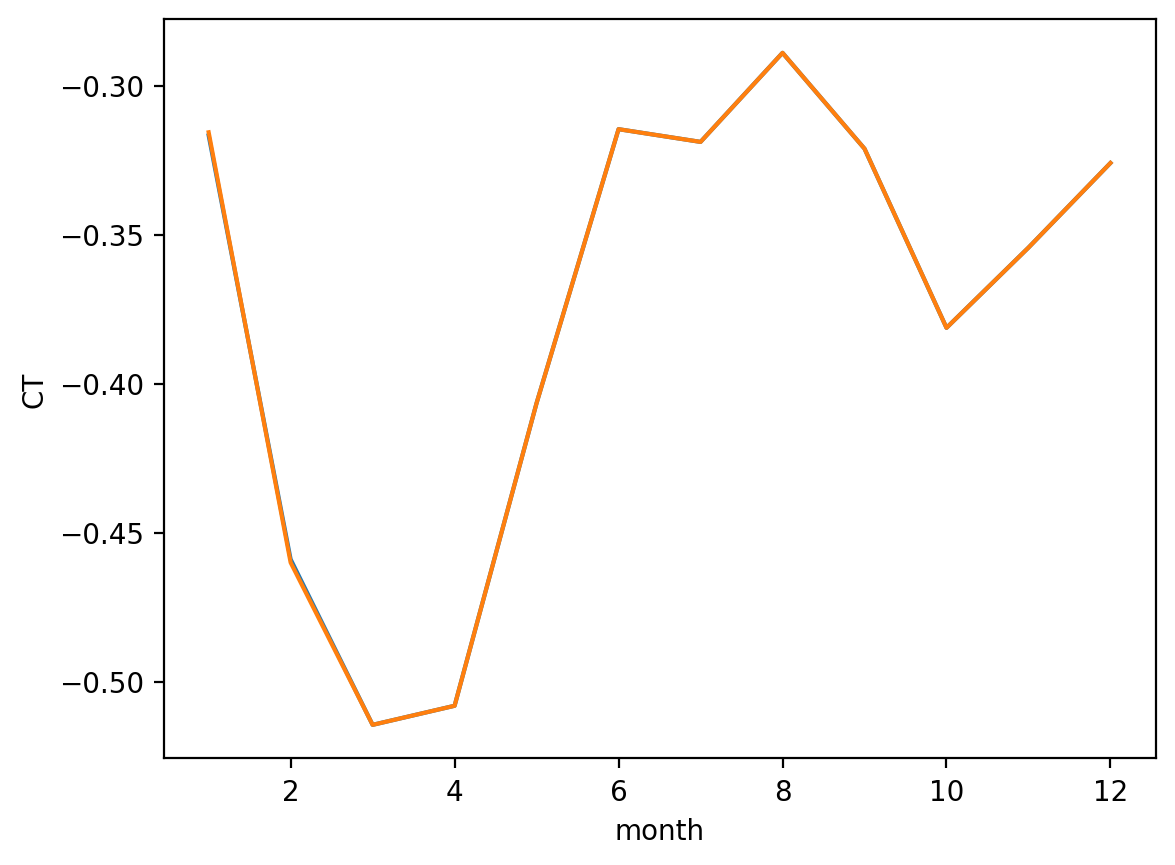

In [39]:
def groupby_weighted_mean(da, group, w):
    num = (da * w).groupby(group).sum('time')
    den = w.groupby(group).sum('time')
    return num / den

groupby_weighted_mean(calm_monthly, 'time.month', calm_monthly.time.dt.days_in_month).plot()
calm_clim.plot()

## Extract simulated temperature for the mooring locations

In [33]:
mertz_moved = [139-360, -65.3]
mertz_moved2 = [142-360, -65.4]
# model_mertz2_temp= bottom_temp.sel(xt_ocean=np.array(mertz_lon).mean()-360,method='nearest').sel(yt_ocean=np.array(mertz_lat).mean(),method='nearest')
model_mertz2_temp = bottom_temp.sel(xt_ocean=mertz_moved[0], method='nearest').sel(yt_ocean=mertz_moved[1], method='nearest')
model_mertz2_temp_clim = model_mertz2_temp.groupby('time.month').mean('time')
model_mertz2_temp_range_annual = model_mertz2_temp.groupby('time.year').max('time') - model_mertz2_temp.groupby('time.year').min('time')

# for CALM, I don't use digital subscript as both calm1 and calm2 datasets are from the same mooring (different instruments)
model_calm_temp = bottom_temp.sel(xt_ocean=np.array(calm_lon).mean()-360, method='nearest').sel(yt_ocean=np.array(calm_lat).mean(), method='nearest')
model_calm_temp_clim = model_calm_temp.groupby('time.month').mean('time')
model_calm_temp_range_annual = model_calm_temp.groupby('time.year').max('time') - model_calm_temp.groupby('time.year').min('time')


# KOMBI
model_kombi_temp = bottom_temp.sel(xt_ocean=kombi.longitude, method='nearest').sel(yt_ocean=kombi.latitude, method='nearest')
model_kombi_temp_clim = model_kombi_temp.groupby('time.month').mean('time')
model_kombi_temp_range_annual = model_kombi_temp.groupby('time.year').max('time') - model_kombi_temp.groupby('time.year').min('time')

# AWI
model_awi_temp = bottom_temp.sel(xt_ocean=np.array(awi_lon).mean(), method='nearest').sel(yt_ocean=np.array(awi_lat).mean(), method='nearest')
model_awi_temp_clim = model_awi_temp.groupby('time.month').mean('time')
model_awi_temp_range_annual = model_awi_temp.groupby('time.year').max('time') - model_awi_temp.groupby('time.year').min('time')

# std 
model_calm_temp_clim_std = model_calm_temp.groupby('time.month').std('time',ddof=1)
model_mertz2_temp_clim_std = model_mertz2_temp.groupby('time.month').std('time',ddof=1)
model_kombi_temp_clim_std = model_kombi_temp.groupby('time.month').std('time',ddof=1)
model_awi_temp_clim_std = model_awi_temp.groupby('time.month').std('time',ddof=1)

# compute month of minimum temp for every year 
model_calm_minT_month = model_calm_temp.groupby('time.year').apply(lambda x: x.argmin(dim='time')+1)
model_calm_minT_month = model_mertz2_temp.groupby('time.year').apply(lambda x: x.argmin(dim='time')+1)
model_calm_minT_month = model_kombi_temp.groupby('time.year').apply(lambda x: x.argmin(dim='time')+1)
model_awi_minT_month = model_awi_temp.groupby('time.year').apply(lambda x: x.argmin(dim='time')+1)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


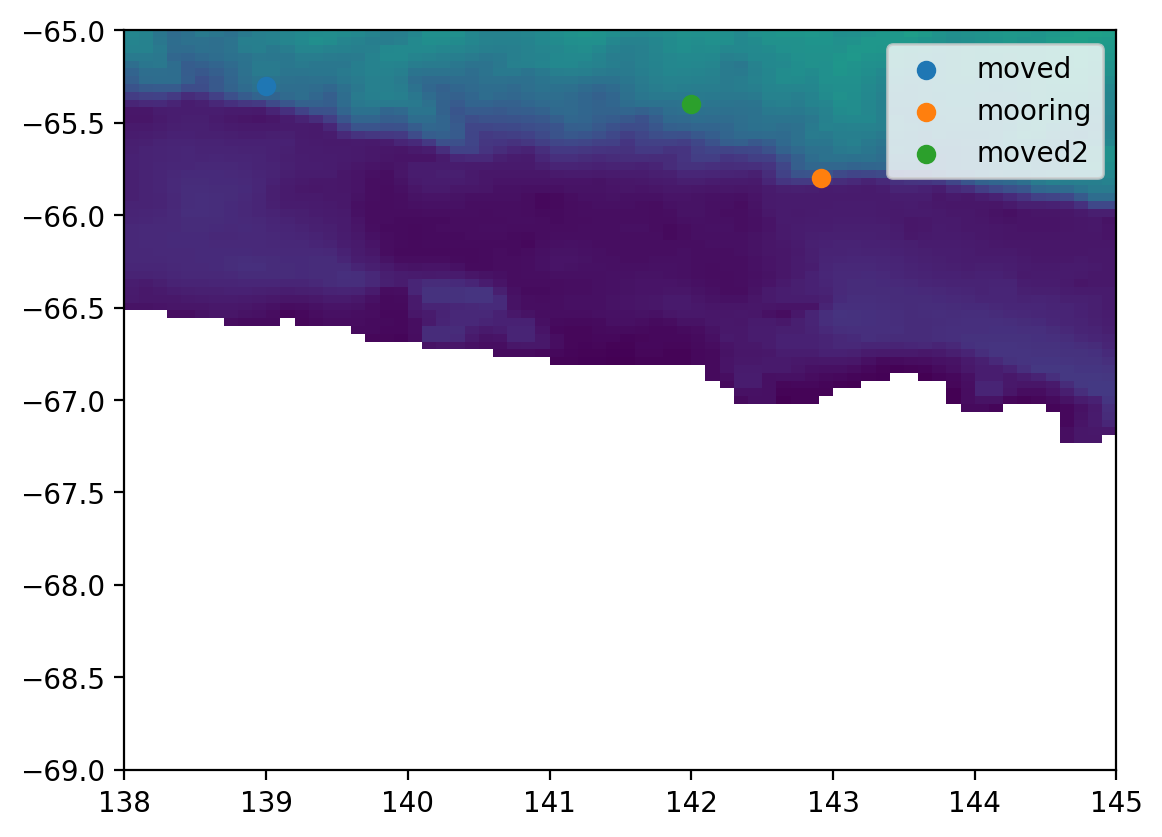

In [34]:
plt.pcolormesh(ht.xt_ocean+360, ht.yt_ocean, ht) 
plt.xlim(-222+360, -215+360)
plt.ylim(-69, -65)
plt.scatter(mertz_moved[0]+360, mertz_moved[1],  label='moved')
plt.scatter(mertz2_clim.lon, mertz2_clim.lat, label='mooring')
plt.scatter(mertz_moved2[0]+360, mertz_moved2[1], label='moved2')
plt.legend()

In [40]:
model_mertz2_temp_clim = model_mertz2_temp_clim.load()
model_mertz2_temp_range_annual = model_mertz2_temp_range_annual.load()

model_calm_temp_clim = model_calm_temp_clim.load()
model_calm_temp_range_annual = model_calm_temp_range_annual.load()

model_kombi_temp_clim = model_kombi_temp_clim.load()
model_kombi_temp_range_annual = model_kombi_temp_range_annual.load()

model_awi_temp_clim = model_awi_temp_clim.load()
model_awi_temp_range_annual = model_awi_temp_range_annual.load()

model_calm_temp_clim_std = model_calm_temp_clim_std.load()
model_mertz2_temp_clim_std = model_mertz2_temp_clim_std.load()
model_kombi_temp_clim_std = model_kombi_temp_clim_std.load()
model_awi_temp_clim_std = model_awi_temp_clim_std.load()


model_calm_minT_month = model_calm_minT_month.load()
model_calm_minT_month = model_calm_minT_month.load()
model_calm_minT_month = model_calm_minT_month.load()
model_awi_minT_month = model_awi_minT_month.load()

In [46]:
model_mertz2_temp

<xarray.DataArray 'temp' (time: 732)> Size: 3kB
dask.array<getitem, shape=(732,), dtype=float32, chunksize=(144,), chunktype=numpy.ndarray>
Coordinates:
    xt_ocean  float64 8B -221.0
    yt_ocean  float64 8B -65.31
  * time      (time) datetime64[ns] 6kB 1958-01-16T12:00:00 ... 2018-12-16T12...

## Make Figure 

In [16]:
# Helper function used for visualization in the following examples
def identify_axes(ax_dict, fontsize=48):
    """
    Helper to identify the Axes in the examples below.

    Draws the label in a large font in the center of the Axes.

    Parameters
    ----------
    ax_dict : dict[str, Axes]
        Mapping between the title / label and the Axes.
    fontsize : int, optional
        How big the label should be.
    """
    kw = dict(ha="center", va="center", fontsize=fontsize, color="darkgrey")
    for k, ax in ax_dict.items():
        ax.text(0.5, 0.5, k, transform=ax.transAxes, **kw)

In [41]:
theta  = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.45
verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)


In [42]:
# To plot 1000-m contour
contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
shelf = contour_file['contour_masked_above']
yt_ocean = contour_file['yt_ocean']
xt_ocean = contour_file['xt_ocean']
# Mask values that are non-zero
shelf[np.where(shelf!=0)] = np.nan
shelf = shelf+1
shelf = np.nan_to_num(shelf)
shelf = xr.DataArray(shelf, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])

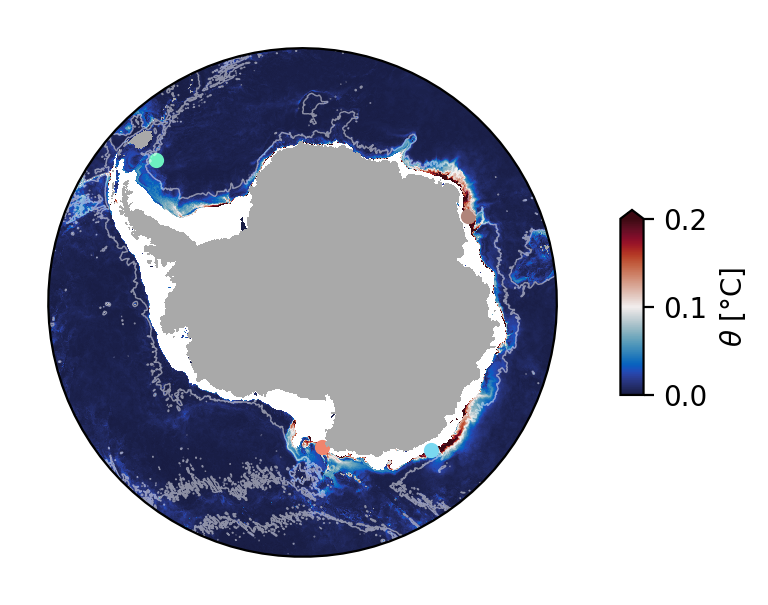

In [23]:
fig = plt.figure(1, figsize=(4,4))
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo(), facecolor="darkgrey")
ax.set_boundary(circle, transform=ax.transAxes)
cmap=cmocean.balance

# Filled land 
land.plot.contourf(ax=ax, colors='darkgrey',
                   zorder=2,
                   transform=ccrs.PlateCarree(),
                   add_colorbar=False)
ax.contourf(shelf.xt_ocean, shelf.yt_ocean, shelf, [0.5, 1], transform=ccrs.PlateCarree(), colors='white')

temp_range.plot.pcolormesh(ax=ax, cmap=cmap,
                            vmin=0, vmax=0.2,
                            transform=ccrs.PlateCarree(),
                            cbar_kwargs={'orientation': 'vertical',
                                          'shrink': 0.25,
                                          'extend': 'max',
                                          'label': None,
                                          'aspect': 8, 
                                          'label': r'$\theta$ '+f'[{degree}C]'
                                         })

# Depth contours
ht.plot.contour(ax=ax, levels=[3500],
                colors='w', linewidths=[0.5], alpha=0.5,
                transform=ccrs.PlateCarree())

ax.scatter(model_awi_temp.xt_ocean, model_awi_temp.yt_ocean, s=20, marker='o', color=colors[0], transform=ccrs.PlateCarree())
ax.scatter(model_kombi_temp.xt_ocean, model_kombi_temp.yt_ocean, s=20, marker='o', color=colors[1], transform=ccrs.PlateCarree())
ax.scatter(model_mertz2_temp.xt_ocean, model_mertz2_temp.yt_ocean, s=20, marker='o', color=colors[2], transform=ccrs.PlateCarree())
ax.scatter(model_calm_temp.xt_ocean, model_calm_temp.yt_ocean, s=20, marker='o', color=colors[3], transform=ccrs.PlateCarree())


plt.tight_layout()

- Reduce white space (specify axes coordinates)
- Add subplot annotations
- Change colour-coding
- Change colours of obsrved seasonal cycle line and range dots according to the region colour


In [32]:
kombi_clim_std

<xarray.Dataset> Size: 576B
Dimensions:      (month: 12)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    temperature  (month) float64 96B 0.06082 0.1102 0.1037 ... 0.1061 0.06461
    salinity     (month) float64 96B 0.003458 0.01303 ... 0.008224 0.003617
    pressure     (month) float64 96B 0.3203 0.2792 0.2478 ... 0.3007 0.3091
    SA           (month) float64 96B 0.003476 0.01309 ... 0.008265 0.003635
    CT           (month) float64 96B 0.05115 0.121 0.1021 ... 0.09015 0.06287
Attributes:
    station:    KOMBI_2
    latitude:   -66.52
    longitude:  62.45
    depth:      1730
    source:     CTD mooring

NameError: name 'circle' is not defined

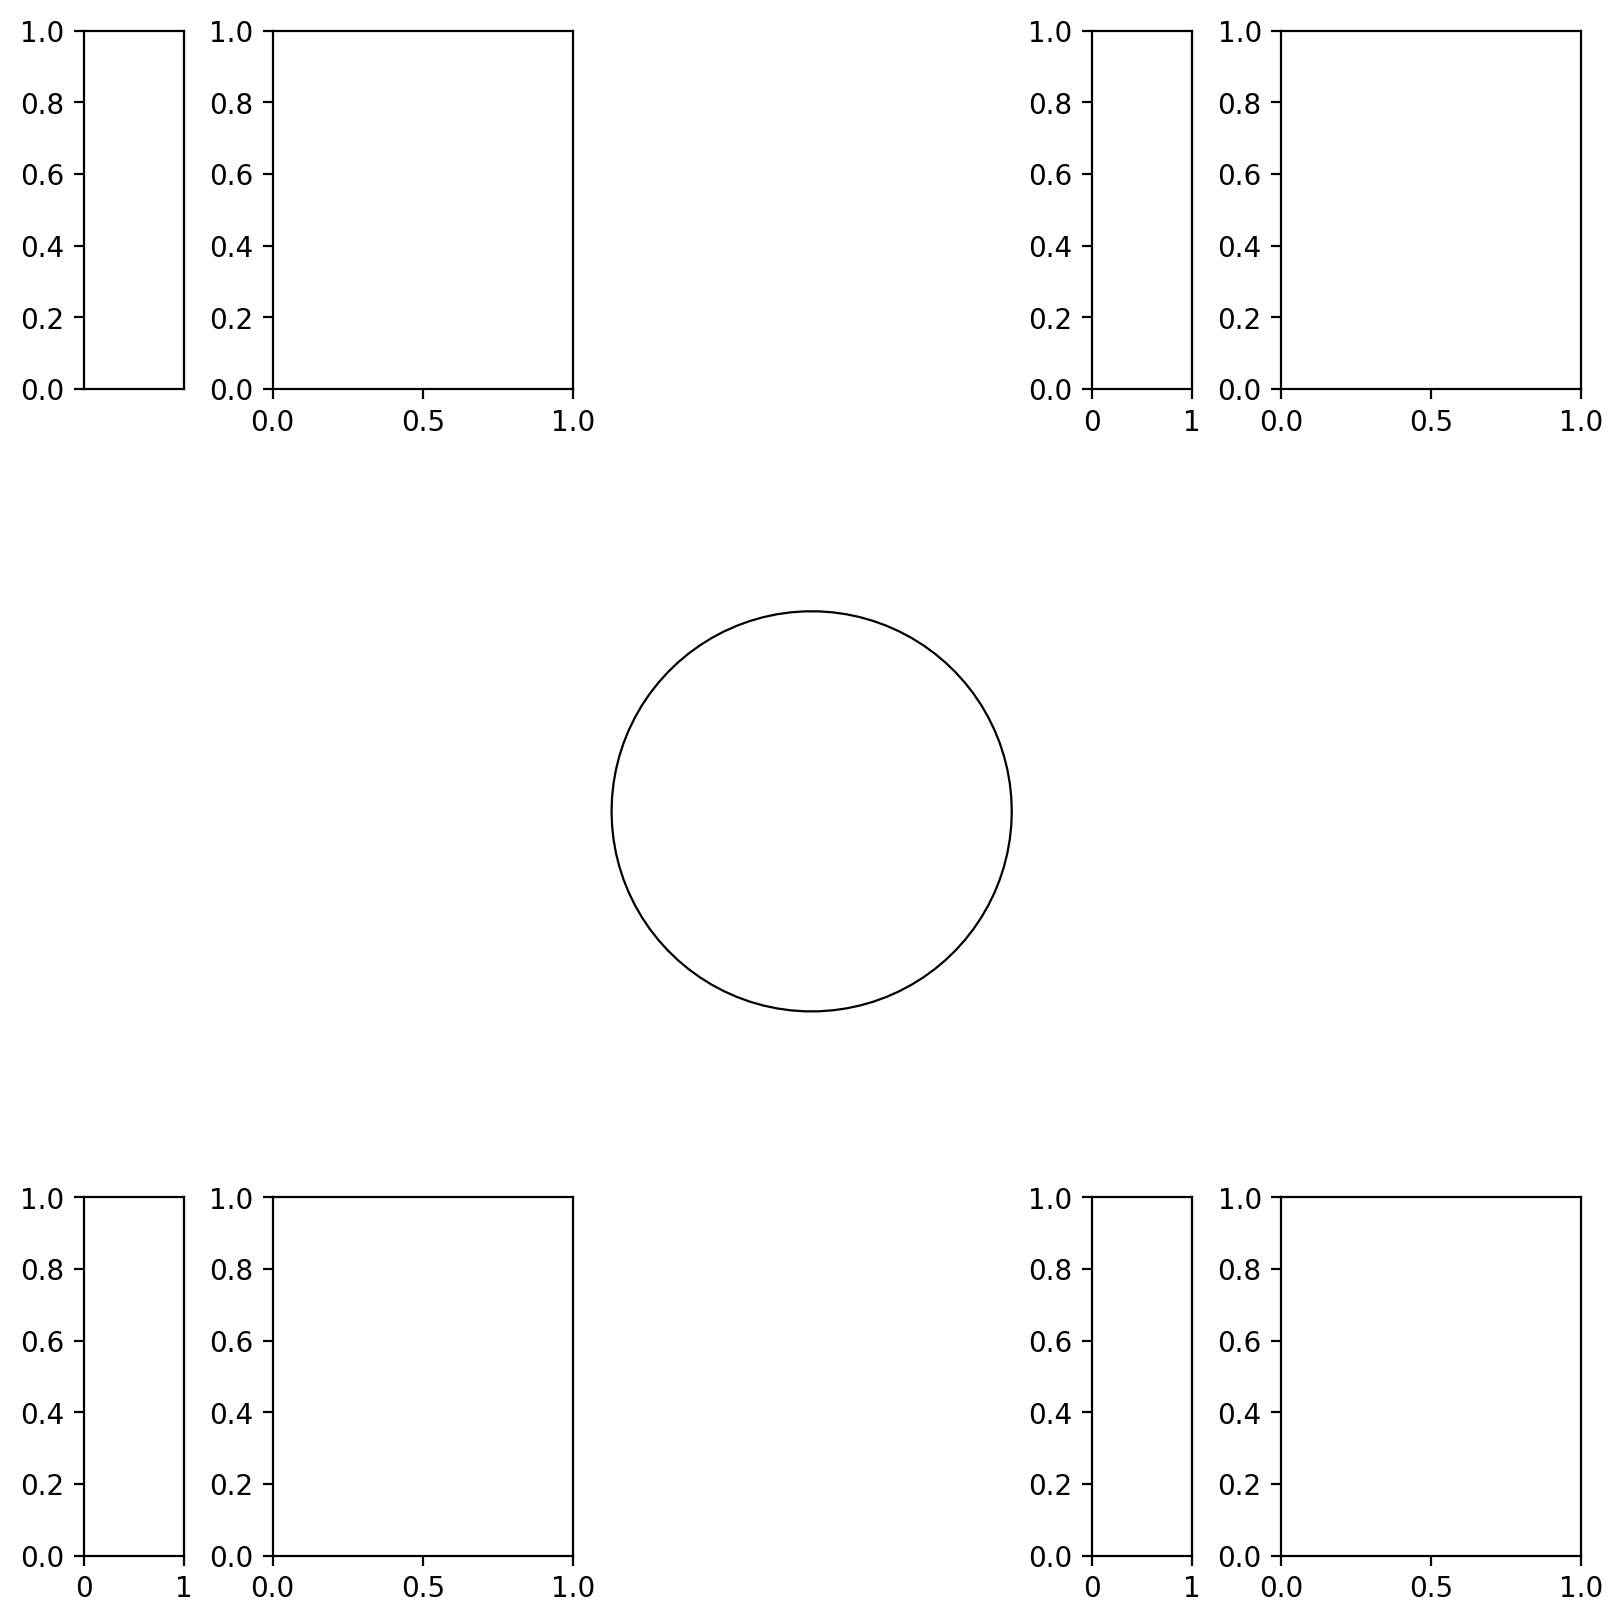

In [51]:
fig, axd = plt.subplot_mosaic(
    "ABBB....CDDD;....EEEE....;FGGG....HIII",
    per_subplot_kw={
        "E": {"projection": ccrs.SouthPolarStereo()}, #
    },
    height_ratios=[0.5,1,0.5],
    figsize=(8,8),
    constrained_layout=True
)
# identify_axes(axd)

colors = ['#6CF0C0',  '#B0857B', '#7AD8F0', '#F0846D',  '#C2B78B', '#70625F']
model_color =  colors[-1]
obs_color = colors[3]
boxwidth = 0.4


axd['A'].axes.get_xaxis().set_visible(False)
axd['E'].set_boundary( circle, transform=axd['E'].transAxes)


# Coastline
# land.fillna(0).plot.contour(ax=axd['E'], colors='k', levels=[0, 1],
#                             transform=ccrs.PlateCarree(),
#                             add_colorbar=False)

# Depth contours
ht.plot.contour(ax=axd['E'], levels=[3500],
                colors='0.2', linewidths=[0.5], alpha=0.5,
                transform=ccrs.PlateCarree())
cmap=cmocean.balance
temp_range.plot.pcolormesh(ax=axd['E'], cmap=cmap,
                           vmin=0, vmax=0.2,
                            transform=ccrs.PlateCarree(),
                            cbar_kwargs={'orientation': 'vertical',
                                         'shrink': 0.25,
                                         'extend': 'max',
                                         'label': None,
                                         'aspect': 8, 
                                         'label': r'$\theta$ '+f'[{degree}C]'
                                        }) 
# Filled land 
land.plot.contourf(ax=axd['E'], colors='darkgrey',
                   # zorder=2,
                   transform=ccrs.PlateCarree(),
                   add_colorbar=False)

axd['E'].contourf(shelf.xt_ocean, shelf.yt_ocean, shelf, [0.5, 1], transform=ccrs.PlateCarree(), colors='white')
axd['E'].scatter(model_awi_temp.xt_ocean, model_awi_temp.yt_ocean, s=20, marker='o', color=colors[0], transform=ccrs.PlateCarree())
axd['E'].scatter(model_kombi_temp.xt_ocean, model_kombi_temp.yt_ocean, s=20, marker='o', color=colors[1], transform=ccrs.PlateCarree())
axd['E'].scatter(model_mertz2_temp.xt_ocean, model_mertz2_temp.yt_ocean, s=20, marker='o', color=colors[2], transform=ccrs.PlateCarree())
axd['E'].scatter(model_calm_temp.xt_ocean, model_calm_temp.yt_ocean, s=20, marker='o', color=colors[3], transform=ccrs.PlateCarree())


##### WEDDELL SEA #########
# Weddell Sea: box plot: temp range 
bp = axd['A'].boxplot(model_awi_temp_range_annual, widths=boxwidth)
axd['A'].set_ylim(0,0.2)
for i, c in zip((awi_range_annual.CT1+awi_range_annual.CT2)/2, colors):
    axd['A'].plot(1, i, marker='o', markersize=5, c=c)
for median in bp['medians']:
    median.set_color('black')


# Weddell Sea : climatology plot 
axd['B'].plot(model_awi_temp_clim.month, model_awi_temp_clim, c=model_color, label='model')
axd['B'].fill_between(model_awi_temp_clim.month,
                     model_awi_temp_clim+model_awi_temp_clim_std, 
                     model_awi_temp_clim-model_awi_temp_clim_std,
                     alpha=0.1, 
                     color=model_color)
axd['B'].plot(awi.month, (awi_clim.CT1+awi_clim.CT2)/2, c=obs_color, label='obs')

##### PRYDZ BAY #########
# Prydz Bay: box plot: temp range 
bp = axd['C'].boxplot(model_kombi_temp_range_annual, widths=boxwidth)
for i, c in zip(kombi_range_annual.CT, colors):
    axd['C'].plot(1, i, marker='o', markersize=5, c=c)
for median in bp['medians']:
    median.set_color('black')

# Prydz Bay: climatology plot
axd['D'].plot(model_kombi_temp_clim.month, model_kombi_temp_clim, c=model_color, label='model')
axd['D'].fill_between(model_kombi_temp_clim.month, 
                        model_kombi_temp_clim +
                        model_kombi_temp_clim_std,
                        model_kombi_temp_clim -
                        model_kombi_temp_clim_std,
                      alpha=0.1,
                      color=model_color
)
axd['D'].plot(kombi_clim.month, kombi_clim.CT, c=obs_color, label='obs')
    

##### ROSS SEA ##########
# Ross Sea: box plot: temp range 
bp=axd['F'].boxplot(model_calm_temp_range_annual, widths=boxwidth)
# axd['F'].set_ylabel(r'$\theta$ '+ f'[{degree}C]')
for i, c in zip(calm1_range_annual.CT[:-1], colors):
    axd['F'].plot(1, i, marker='o', markersize=5, c=c)
for median in bp['medians']:
    median.set_color('black')

# Ross Sea: climatology plot 
axd['G'].plot(model_calm_temp_clim.month, model_calm_temp_clim, c=model_color, label='model')
axd['G'].fill_between(model_calm_temp_clim.month,
                      model_calm_temp_clim + 
                     model_calm_temp_clim_std, 
                     model_calm_temp_clim - 
                     model_calm_temp_clim_std, 
                     alpha=0.1, 
                     color=model_color)
axd['G'].plot(calm1_clim.month, calm1_clim.CT, c=obs_color, label='obs')


####### Adélie Land ############
# Adélie Land: box plot: temp range 
bp = axd['H'].boxplot(model_mertz2_temp_range_annual, widths=boxwidth)
axd['H'].plot(1, mertz2_range.CT, marker='o', markersize=5, c=obs_color)
for median in bp['medians']:
    median.set_color('black')

# Adélie LandL climatology : line plot 
axd['I'].plot(model_mertz2_temp_clim.month, model_mertz2_temp_clim, c=model_color, label='model')
axd['I'].fill_between(model_mertz2_temp_clim.month, 
                      model_mertz2_temp_clim + 
                     model_mertz2_temp_clim_std, 
                     model_mertz2_temp_clim - 
                     model_mertz2_temp_clim_std,
                     alpha=0.1,
                     color=model_color)
axd['I'].plot(mertz2_clim.month, mertz2_clim.CT, c=obs_color, label='obs')

lineplots = [axd['B'], axd['D'], axd['G'], axd['I']]
for p in lineplots:
    p.legend(fontsize=7)
    p.set_xticks([1, 3, 5, 7, 9, 11])
    p.set_xticklabels(['J', 'M', 'M', 'J', 'S', 'N'], fontsize=10)
    p.grid(axis='both', alpha=0.6, linestyle=':')
    p.set_ylim(-1,0)
    p.set_xlim(1,12)

boxplots = [axd['C'], axd['F'], axd['H']]
for p in boxplots:
    p.set_ylabel(r'$\theta$ '+ f'[{degree}C]')
    p.set_ylim(0,1)
    p.axes.get_xaxis().set_visible(False)

# plt.savefig(f'{figdir}/model_obs_comparison.png', dpi=300)
    

/jobfs/167010472.gadi-pbs/ipykernel_390334/2656008501.py:202: UserWarning: The following kwargs were not used by contour: 'expand'
  cf=axd['I'].contourf(ht_rewrap.xt_ocean, ht_rewrap.yt_ocean, ht_rewrap, levels=np.arange(0,6000,500), cmap=cmcrameri.cm.oslo_r, expand='max')


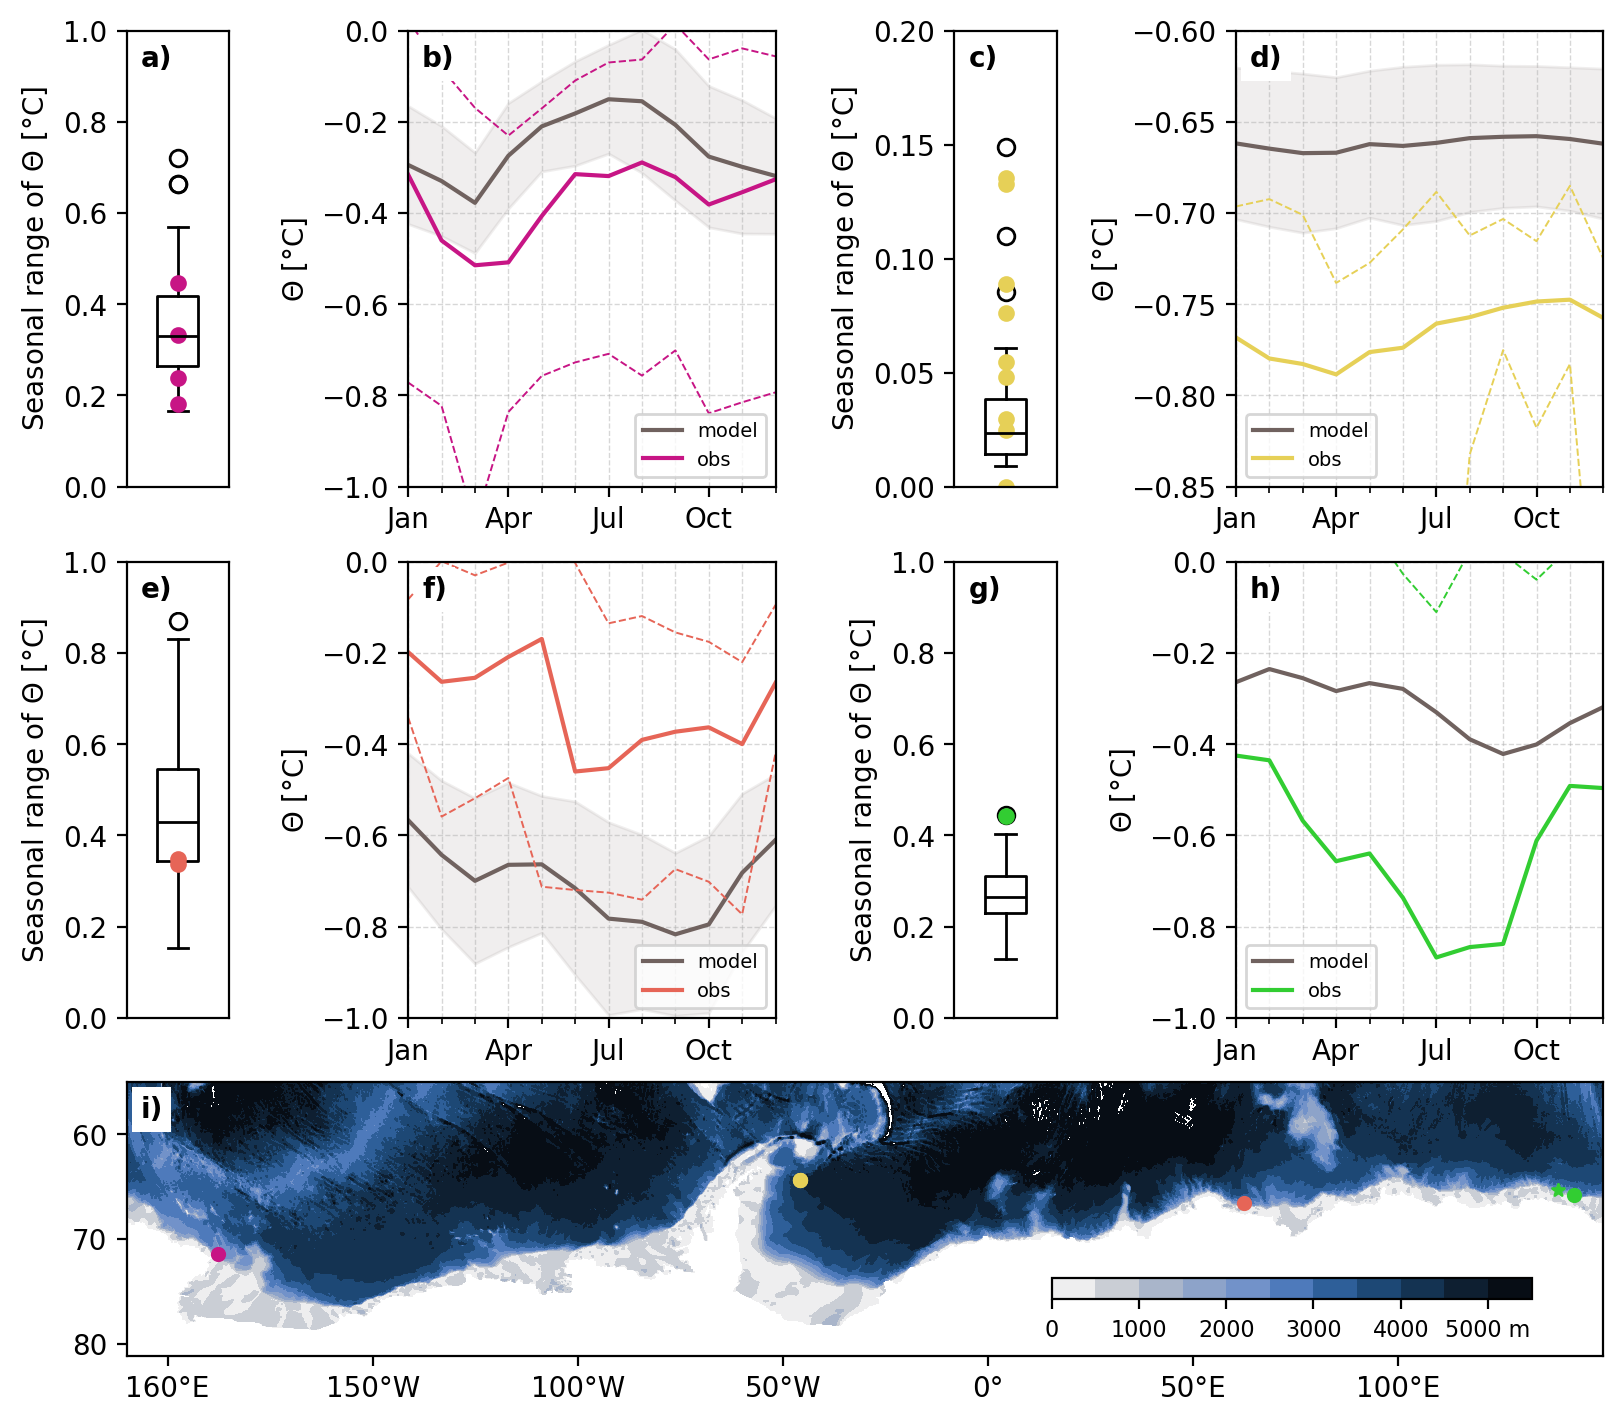

In [48]:
fig, axd = plt.subplot_mosaic(
    "ABBCDD;EFFGHH;IIIIII",
    figsize=(8,7),
    height_ratios=[1,1,0.6],
    constrained_layout=True
)

colors = ['#6CF0C0',  '#B0857B', '#7AD8F0', '#F0846D',  '#C2B78B', '#70625F']
model_color =  colors[-1]
obs_color = colors[3]
boxwidth = 0.4

c_weddell = '#E6D057'
c_prydz = '#E66557'
# c_adelie = '#58E69B'
c_adelie = 'limegreen'
# c_ross = '#6357E6'
c_ross = 'mediumvioletred'

##### WEDDELL SEA #########
# Weddell Sea: box plot: temp range 
bp = axd['C'].boxplot(model_awi_temp_range_annual, widths=boxwidth)
axd['C'].set_ylim(0,0.2)
for i in awi217_range_annual:
    axd['C'].plot(1, i, marker='o', markersize=5, c=c_weddell)
for median in bp['medians']:
    median.set_color('black')

# Weddell Sea : climatology plot 
axd['D'].plot(model_awi_temp_clim.month, model_awi_temp_clim, c=model_color, label='model')
axd['D'].fill_between(model_awi_temp_clim.month,
                     model_awi_temp_clim+model_awi_temp_clim_std, 
                     model_awi_temp_clim-model_awi_temp_clim_std,
                     alpha=0.1, 
                     color=model_color)
axd['D'].plot(awi217_clim.month, awi217_clim, c=c_weddell, label='obs')
axd['D'].plot(awi217_clim.month,
              awi217_clim_min,
              alpha=1,
              linestyle='--',
              linewidth=0.7,
              color=c_weddell
)
axd['D'].plot(awi217_clim.month,
              awi217_clim_max,
              alpha=1,
              linestyle='--',
              linewidth=0.7,
              color=c_weddell
)

##### PRYDZ BAY #########
# Prydz Bay: box plot: temp range 
bp = axd['E'].boxplot(model_kombi_temp_range_annual, widths=boxwidth)
for i in kombi_range_annual.CT:
    axd['E'].plot(1, i, marker='o', markersize=5, c=c_prydz)
for median in bp['medians']:
    median.set_color('black')

# Prydz Bay: climatology plot
axd['F'].plot(model_kombi_temp_clim.month, model_kombi_temp_clim, c=model_color, label='model')
axd['F'].fill_between(model_kombi_temp_clim.month, 
                        model_kombi_temp_clim +
                        model_kombi_temp_clim_std,
                        model_kombi_temp_clim -
                        model_kombi_temp_clim_std,
                      alpha=0.1,
                      color=model_color
)
axd['F'].plot(kombi_clim.month, kombi_clim.CT, c=c_prydz, label='obs')
axd['F'].plot(kombi_clim.month,
              kombi_clim_min.CT,
              alpha=1,
              linestyle='--',
              linewidth=0.7,
              color=c_prydz
)
axd['F'].plot(kombi_clim.month,
              kombi_clim_max.CT,
              alpha=1,
              linestyle='--',
              linewidth=0.7,
              color=c_prydz
)
# axd['F'].fill_between(kombi_clim.month, 
#                      kombi_clim.CT - kombi_clim_std.CT, 
#                       kombi_clim.CT + kombi_clim_std.CT,
#                       alpha=0.1, 
#                       color=c_prydz
#                      )

##### ROSS SEA ##########
# Ross Sea: box plot: temp range 
bp=axd['A'].boxplot(model_calm_temp_range_annual, widths=boxwidth)
# axd['F'].set_ylabel(r'$\theta$ '+ f'[{degree}C]')
for i in calm_range_annual:
    axd['A'].plot(1, i, marker='o', markersize=5, c=c_ross)
for median in bp['medians']:
    median.set_color('black')

# Ross Sea: climatology plot 
axd['B'].plot(model_calm_temp_clim.month, model_calm_temp_clim, c=model_color, label='model')
axd['B'].fill_between(model_calm_temp_clim.month,
                      model_calm_temp_clim + 
                     model_calm_temp_clim_std, 
                     model_calm_temp_clim - 
                     model_calm_temp_clim_std, 
                     alpha=0.1, 
                     color=model_color)
axd['B'].plot(calm_clim.month, calm_clim, c=c_ross, label='obs')
axd['B'].plot(calm_clim.month,
              calm_clim_min,
              alpha=1,
              linestyle='--',
              linewidth=0.7,
              color=c_ross
)
axd['B'].plot(calm_clim.month,
              calm_clim_max,
              alpha=1,
              linestyle='--',
              linewidth=0.7,
              color=c_ross
)


# axd['B'].fill_between(calm_clim.month, 
#                       calm_clim - calm_clim_std,
#                       calm_clim + calm_clim_std, 
#                       alpha=0.1, 
#                       color=c_ross
#                      )

####### Adélie Land ############
# Adélie Land: box plot: temp range 
bp = axd['G'].boxplot(model_mertz2_temp_range_annual, widths=boxwidth)
# for i in mertz_range_annual:
axd['G'].plot(1, mertz_range.CT, marker='o', markersize=5, c=c_adelie)
for median in bp['medians']:
    median.set_color('black')

# Adélie Land climatology : line plot 
axd['H'].plot(model_mertz2_temp_clim.month, model_mertz2_temp_clim, c=model_color, label='model')
# axd['H'].fill_between(model_mertz2_temp_clim.month, 
#                       model_mertz2_temp_clim + 
#                      model_mertz2_temp_clim_std, 
#                      model_mertz2_temp_clim - 
#                      model_mertz2_temp_clim_std,
#                      alpha=0.1,
#                      color=model_color)
axd['H'].plot(mertz2_clim.month, mertz2_clim.CT, c=c_adelie, label='obs')
axd['H'].plot(mertz2_clim.month,
              mertz2_clim_min.CT,
              alpha=1,
              linestyle='--',
              linewidth=0.7,
              color=c_adelie
)
axd['H'].plot(mertz2_clim.month,
              mertz2_clim_max.CT,
              alpha=1,
              linestyle='--',
              linewidth=0.7,
              color=c_adelie
)
lineplots = [axd['B'], axd['D'], axd['F'], axd['H']]
for p in lineplots:
    p.legend(fontsize=7)
    p.set_xticks([1, 4, 7, 10])
    p.set_xticklabels(['Jan', 'Apr', 'Jul', 'Oct'], fontsize=10)
    p.grid(axis='both', alpha=0.6, linestyle=':')
    p.set_ylim(-1,0)
    p.set_xlim(1,12)
    p.xaxis.set_minor_locator(MultipleLocator(1))
    p.grid(which='both', linestyle='--', alpha=0.5, linewidth=0.5)
    p.set_ylabel(r'$\Theta$ '+ f'[{degree}C]')
    if p==axd['D']:
        p.set_ylim(-.85,-.6)
    
boxplots = [axd['A'], axd['C'], axd['E'], axd['G']]
for p in boxplots:
    p.set_ylabel(r'Seasonal range of $\Theta$ '+ f'[{degree}C]')
    p.set_ylim(0,1)
    p.axes.get_xaxis().set_visible(False)
    if p == axd['C']:
        p.set_ylim(0, 0.2)
        p.set_yticks([0, 0.05, 0.1, 0.15, 0.2])

plots= [axd['A'], axd['B'], axd['C'], axd['D'], axd['E'], axd['F'], axd['G'], axd['H'], axd['I']]
labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)'] 
for p, l in zip(plots, labels):
    p.annotate(
        l,
        xy=(0.0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=10, verticalalignment='top', fontfamily='sans-serif',
        fontweight=550,
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))


## MAP plot 
cf=axd['I'].contourf(ht_rewrap.xt_ocean, ht_rewrap.yt_ocean, ht_rewrap, levels=np.arange(0,6000,500), cmap=cmcrameri.cm.oslo_r, expand='max')
axd['I'].scatter(np.array(calm_lon).mean()-360, np.array(calm_lat).mean(), s=20, color=c_ross)
axd['I'].scatter(awi_lon, awi_lat, s=20, color=c_weddell)
axd['I'].scatter(mertz_moved[0]+360, mertz_moved[1], s=20, marker='*', c=c_adelie)
axd['I'].scatter(mertz_lon, mertz_lat, s=20, c=c_adelie)
axd['I'].scatter(kombi.longitude, kombi.latitude, s=20, c=c_prydz)
axd['I'].set_yticks([-80,-70,-60])
axd['I'].set_yticklabels(['80', '70', '60'])
axd['I'].set_xticks([-200, -150, -100, -50, 0, 50, 100])
axd['I'].set_xticklabels([f'160{degree}E', f'150{degree}W', f'100{degree}W', f'50{degree}W', f'0{degree}', f'50{degree}E', f'100{degree}E'])

cbar_ax = fig.add_axes([0.65, 0.08, 0.3, 0.015])
cbar = plt.colorbar(cf, cax=cbar_ax,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 1000, 2000, 3000, 4000, 5000],
                     location='bottom'
                    )
cbar.set_ticklabels(['0', '1000', '2000', '3000', '4000', '5000 m'])
cbar.ax.tick_params(labelsize=8) 
plt.savefig(f'{figdir}/model_obs_comparison.png', dpi=300)


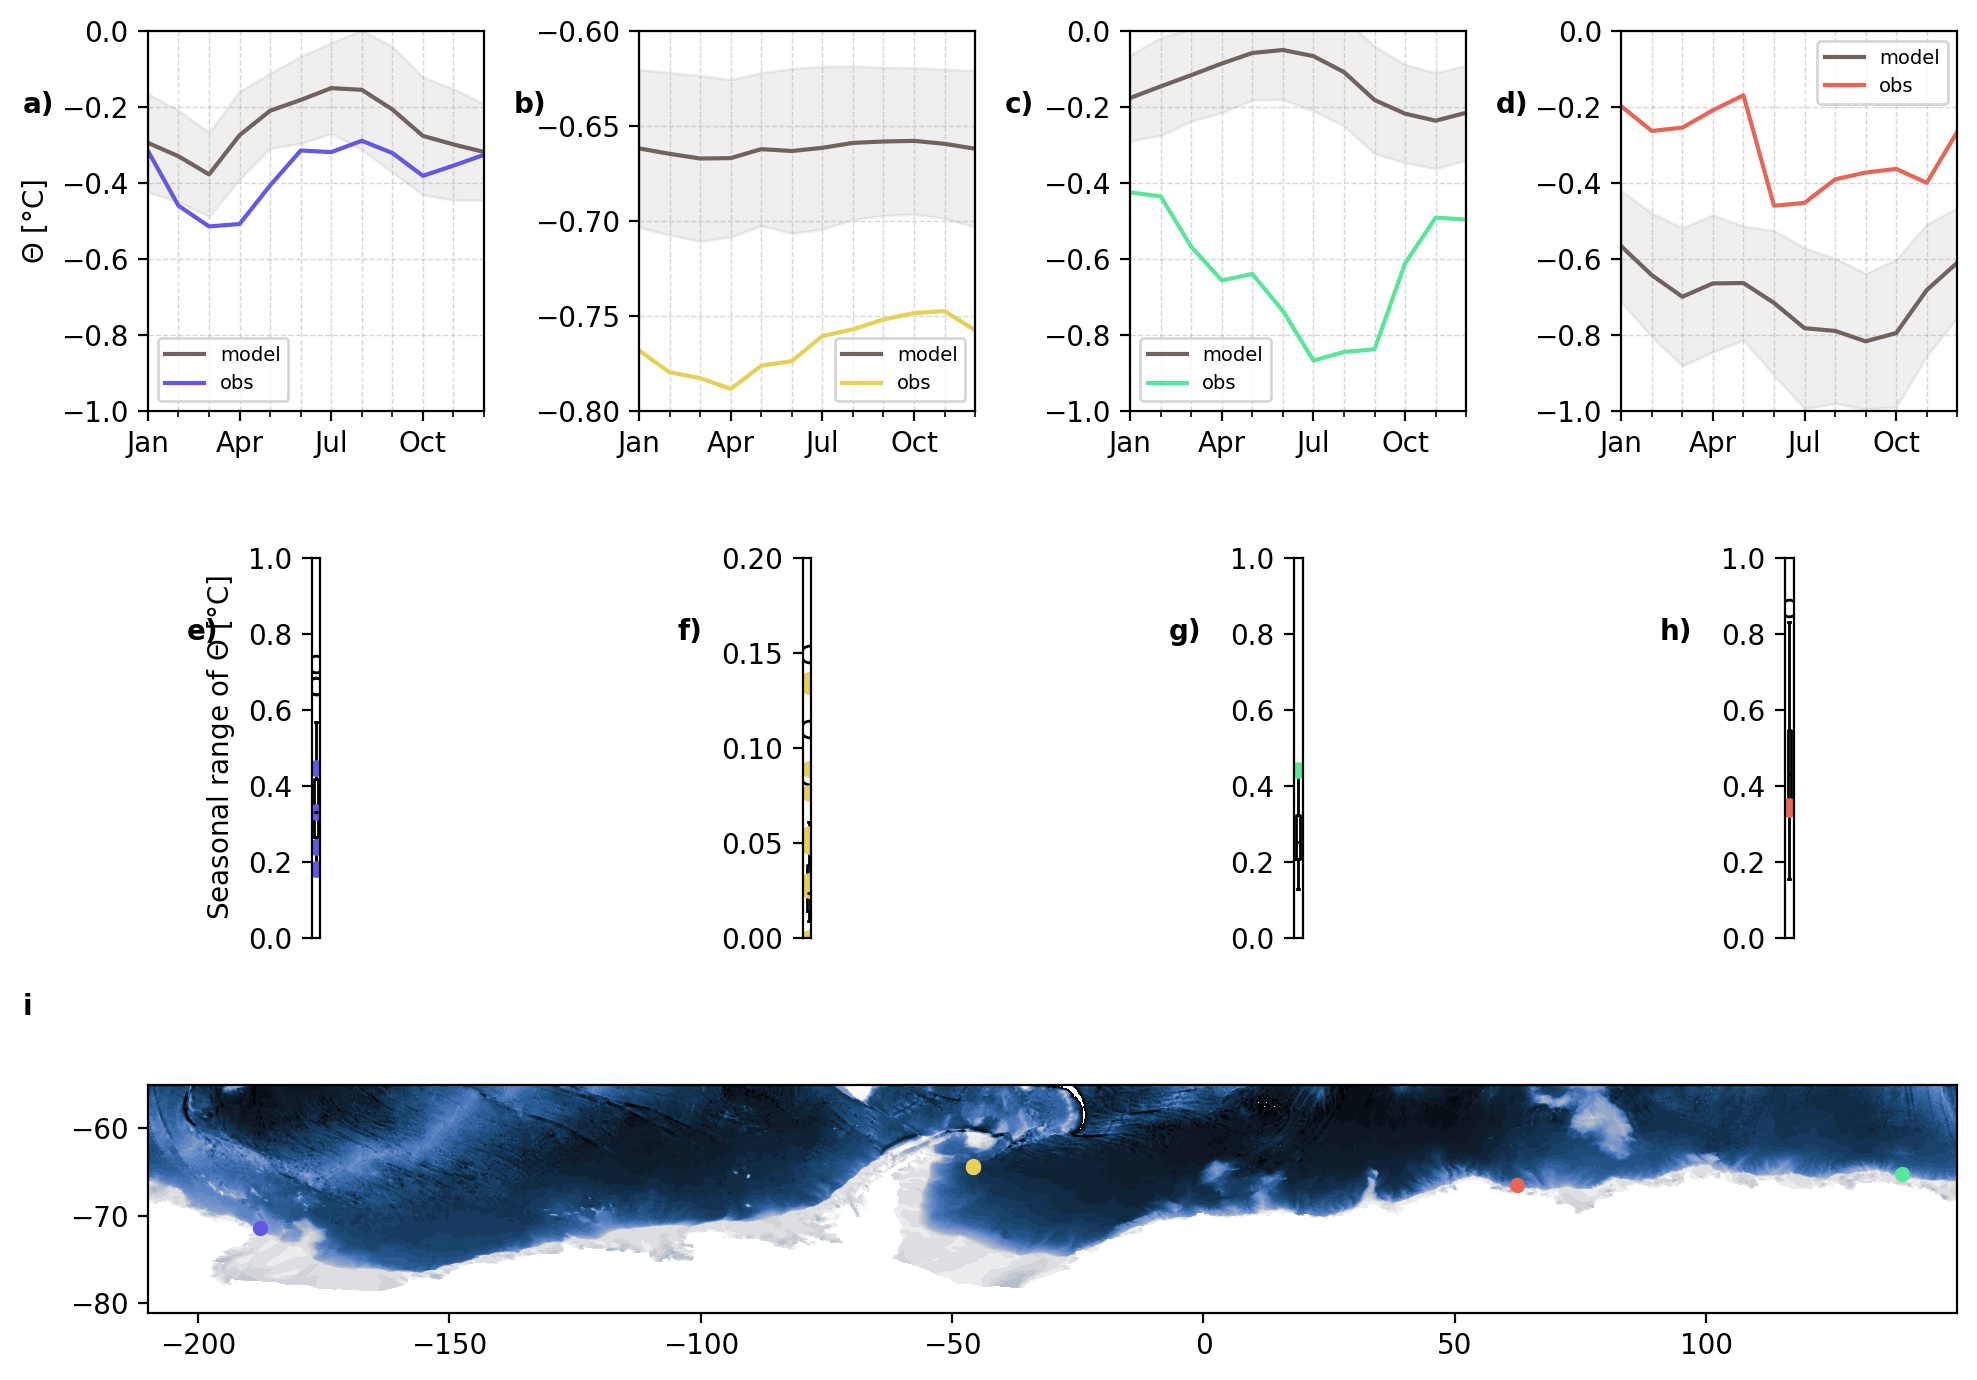

In [54]:
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
fig, axd = plt.subplot_mosaic(
    "AAABBBCCCDDD;.E..F..G..H.;IIIIIIIIIIII",
    figsize=(10,7),
    height_ratios=[1,1,0.6],
)

colors = ['#6CF0C0',  '#B0857B', '#7AD8F0', '#F0846D',  '#C2B78B', '#70625F']
model_color =  colors[-1]
obs_color = colors[3]
boxwidth = 0.4

c_weddell = '#E6D057'
c_prydz = '#E66557'
c_adelie = '#58E69B'
c_ross = '#6357E6'


##### ROSS SEA ##########
# Ross Sea: box plot: temp range 
bp=axd['E'].boxplot(model_calm_temp_range_annual, widths=boxwidth)
# axd['F'].set_ylabel(r'$\theta$ '+ f'[{degree}C]')
for i in calm_range_annual:
    axd['E'].plot(1, i, marker='o', markersize=5, c=c_ross)
for median in bp['medians']:
    median.set_color('black')

# Ross Sea: climatology plot 
axd['A'].plot(model_calm_temp_clim.month, model_calm_temp_clim, c=model_color, label='model')
axd['A'].fill_between(model_calm_temp_clim.month,
                      model_calm_temp_clim + 
                     model_calm_temp_clim_std, 
                     model_calm_temp_clim - 
                     model_calm_temp_clim_std, 
                     alpha=0.1, 
                     color=model_color)
axd['A'].plot(calm_clim.month, calm_clim, c=c_ross, label='obs')

##### WEDDELL SEA #########
# Weddell Sea: box plot: temp range 
bp = axd['F'].boxplot(model_awi_temp_range_annual, widths=boxwidth)
axd['F'].set_ylim(0,0.2)
for i in awi217_range_annual:
    axd['F'].plot(1, i, marker='o', markersize=5, c=c_weddell)
for median in bp['medians']:
    median.set_color('black')


# Weddell Sea : climatology plot 
axd['B'].plot(model_awi_temp_clim.month, model_awi_temp_clim, c=model_color, label='model')
axd['B'].fill_between(model_awi_temp_clim.month,
                     model_awi_temp_clim+model_awi_temp_clim_std, 
                     model_awi_temp_clim-model_awi_temp_clim_std,
                     alpha=0.1, 
                     color=model_color)
axd['B'].plot(awi217_clim.month, awi217_clim, c=c_weddell, label='obs')


####### Adélie Land ############
# Adélie Land: box plot: temp range 
bp = axd['G'].boxplot(model_mertz2_temp_range_annual, widths=boxwidth)
# for i in mertz_range.CT:
axd['G'].plot(1, mertz_range.CT, marker='o', markersize=5, c=c_adelie)
for median in bp['medians']:
    median.set_color('black')

# Adélie Land climatology : line plot 
axd['C'].plot(model_mertz2_temp_clim.month, model_mertz2_temp_clim, c=model_color, label='model')
axd['C'].fill_between(model_mertz2_temp_clim.month, 
                      model_mertz2_temp_clim + 
                     model_mertz2_temp_clim_std, 
                     model_mertz2_temp_clim - 
                     model_mertz2_temp_clim_std,
                     alpha=0.1,
                     color=model_color)
axd['C'].plot(mertz2_clim.month, mertz2_clim.CT, c=c_adelie, label='obs')



##### PRYDZ BAY #########
# Prydz Bay: box plot: temp range 
bp = axd['H'].boxplot(model_kombi_temp_range_annual, widths=boxwidth)
for i in kombi_range_annual.CT:
    axd['H'].plot(1, i, marker='o', markersize=5, c=c_prydz)
for median in bp['medians']:
    median.set_color('black')

# Prydz Bay: climatology plot
axd['D'].plot(model_kombi_temp_clim.month, model_kombi_temp_clim, c=model_color, label='model')
axd['D'].fill_between(model_kombi_temp_clim.month, 
                        model_kombi_temp_clim +
                        model_kombi_temp_clim_std,
                        model_kombi_temp_clim -
                        model_kombi_temp_clim_std,
                      alpha=0.1,
                      color=model_color
)
axd['D'].plot(kombi_clim.month, kombi_clim.CT, c=c_prydz, label='obs')




lineplots = [axd['A'], axd['B'], axd['C'], axd['D']]
for p in lineplots:
    p.legend(fontsize=7)
    p.set_xticks([1, 4, 7, 10])
    p.set_xticklabels(['Jan', 'Apr', 'Jul', 'Oct'], fontsize=10)
    p.grid(axis='both', alpha=0.6, linestyle=':')
    p.set_ylim(-1,0)
    p.set_xlim(1,12)
    p.set_ylabel('')
    p.xaxis.set_minor_locator(MultipleLocator(1))
    p.grid(which='both', linestyle='--', alpha=0.5, linewidth=0.5)
    if p==axd['B']:
        p.set_ylim(-0.8,-.6)
    if p==axd['A']:
        p.set_ylabel(r'$\Theta$ '+ f'[{degree}C]')
    
boxplots = [axd['E'], axd['F'], axd['G'], axd['H']]
for p in boxplots:
    p.set_ylabel('')
    p.set_ylim(0,1)
    p.axes.get_xaxis().set_visible(False)
    if p == axd['F']:
        p.set_ylim(0, 0.2)
        p.set_xticks([0, 0.05, 0.1, 0.15, 0.2])
    if p==axd['E']:
        p.set_ylabel(r'Seasonal range of $\Theta$ '+ f'[{degree}C]')
        

plots= [axd['A'], axd['B'], axd['C'], axd['D'], axd['E'], axd['F'], axd['G'], axd['H'], axd['I']]
labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i'] 
for p, l in zip(plots, labels):
    p.annotate(
        l,
        xy=(-50, 120), xycoords='axes points',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=10, verticalalignment='top', fontfamily='sans-serif',
        fontweight=550)

axd['I'].contourf(ht_rewrap.xt_ocean, ht_rewrap.yt_ocean, ht_rewrap, levels=np.arange(0,6000, 200), cmap=cmcrameri.cm.oslo_r)
axd['I'].scatter(np.array(calm_lon).mean()-360, np.array(calm_lat).mean(), s=20, color=c_ross)
axd['I'].scatter(awi_lon, awi_lat, s=20, color=c_weddell)
axd['I'].scatter(mertz_moved[0]+360, mertz_moved[1], s=20, c=c_adelie)
axd['I'].scatter(kombi.longitude, kombi.latitude, s=20, c=c_prydz)
plt.tight_layout()

plt.savefig(f'{figdir}/model_obs_comparison.png', dpi=300)


In [53]:
calm_lon

[172.3894, 172.385]

In [65]:
# Load data
rsbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/RSBW_range_detrended_1968-2018.nc')
albw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/ALBW_range_detrended_1968-2018.nc')
wsbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/WSBW_range_detrended_1968-2018.nc')
pbbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/PBBW_range_detrended_1968-2018.nc')

rsbw_range = rsbw_range['RSBW_range']
albw_range = albw_range['ALBW_range']
wsbw_range = wsbw_range['WSBW_range']
pbbw_range = pbbw_range['PBBW_range']

In [66]:
# Define projection regions with correct orientation
regions = {
    "Ross": {
        "midlon": -215, "minlon": -250, "maxlon": -180,
        "minlat": -76, "maxlat": -60
    },
    "Weddell": {
        "midlon": -40, "minlon": -60, "maxlon": -20,
        "minlat": -76, "maxlat": -60
    },
    "Adelie": {
        "midlon": -230, "minlon": -250, "maxlon": -210,
        "minlat": -70, "maxlat": -60
    },
    "Prydz": {
        "midlon": 55, "minlon": 35, "maxlon": 75,
        "minlat": -70, "maxlat": -60
    }
}

In [67]:
# To plot 1000-m contour
contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
shelf = contour_file['contour_masked_above']
yt_ocean = contour_file['yt_ocean']
xt_ocean = contour_file['xt_ocean']
# Mask values that are non-zero
shelf[np.where(shelf!=0)] = np.nan
shelf = shelf+1
shelf = np.nan_to_num(shelf)
shelf = xr.DataArray(shelf, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])

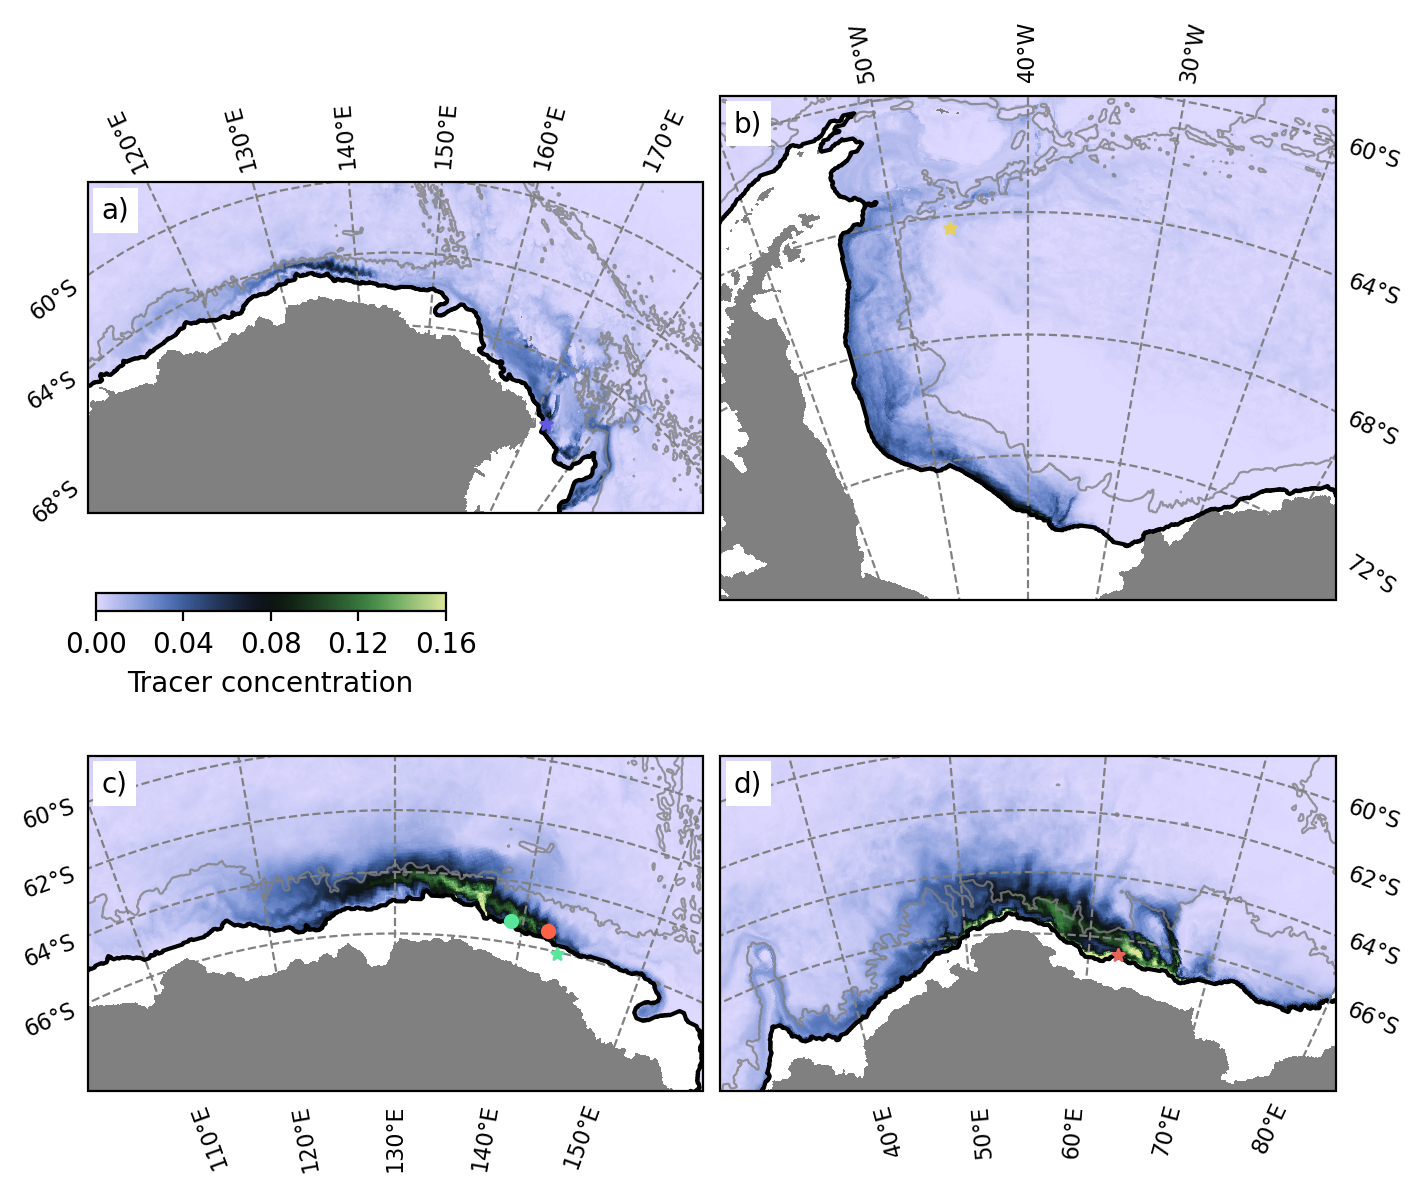

In [95]:
# Set up figure and GridSpec (2 rows x 3 columns)
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig)
norm = mcolors.TwoSlopeNorm(vmin=1, vcenter=6, vmax=12)
# cmap = cmocean.cm.diff
cmap =  cmcrameri.cm.tofino
alpha = 1

c_weddell = '#E6D057'
c_prydz = '#E66557'
c_adelie = '#58E69B'
c_ross = '#6357E6'

# Map region to subplot position (row, col)
subplot_positions = {
    "Ross":  (0, 0),  # Span 2 columns
    "Weddell": (0, 1),
    "Adelie":  (1, 0),
    "Prydz":   (1, 1)
}
fontsize=10
mask_color = 'linen'
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.08, vmax=0.16)
# Plot each region
for name, pos in subplot_positions.items():
    r = regions[name]
    proj = ccrs.Stereographic(central_latitude=-90, central_longitude=r["midlon"])
    ax = fig.add_subplot(gs[pos], projection=proj)
    ax.set_extent([r["minlon"], r["maxlon"], r["minlat"], r["maxlat"]], crs=ccrs.PlateCarree())
    gl=ax.gridlines(draw_labels=True, linestyle='--', color='grey', x_inline=False, y_inline=False)
    ax.spines['geo'].set_visible(True)
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.ylocator = LatitudeLocator()
    gl.xlocator = LongitudeLocator()
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    if name=='Ross':
        pc=ax.pcolormesh(rsbw_range.xt_ocean+360, rsbw_range.yt_ocean, rsbw_range, cmap=cmap, norm=norm, alpha=alpha, transform=ccrs.PlateCarree())
        ax.annotate(
        'a)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.bottom_labels = False
        gl.right_labels = False
        gl.xlocator = mticker.FixedLocator([120, 130, 140, 150, 160, 170, 180])
        gl.ylocator = mticker.FixedLocator([-68, -64, -60])
        ax.scatter(np.array(calm_lon).mean(), np.array(calm_lat).mean(), s=20, marker='*', color=c_ross, transform=ccrs.PlateCarree(), zorder=4)

    if name=='Weddell':
        ax.pcolormesh(wsbw_range.xt_ocean+360, wsbw_range.yt_ocean, wsbw_range, cmap=cmap, norm=norm,  alpha=alpha,transform=ccrs.PlateCarree()) 
        ax.annotate(
        'b)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.bottom_labels = False
        gl.left_labels = False
        gl.ylocator = mticker.FixedLocator([-72, -68, -64, -60]) 
        ax.scatter(np.array(awi_lon).mean(), np.array(awi_lat).mean(), s=20, marker='*', color=c_weddell, transform=ccrs.PlateCarree())


    if name=='Adelie':
        ax.pcolormesh(albw_range.xt_ocean+360, albw_range.yt_ocean, albw_range, cmap=cmap, norm=norm,  alpha=alpha,transform=ccrs.PlateCarree())
        ax.annotate(
        'c)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.right_labels = False
        gl.ylocator = mticker.FixedLocator([-66, -64, -62, -60])
        gl.top_labels = False
        ax.scatter(np.array(mertz_lon).mean(), np.array(mertz_lat).mean(), s=20, marker='*', color=c_adelie, transform=ccrs.PlateCarree(), zorder=4)
        ax.scatter(mertz_moved[0]+360, mertz_moved[1], s=20, marker='o', color=c_adelie, transform=ccrs.PlateCarree(), zorder=4)
        ax.scatter(mertz_moved2[0]+360, mertz_moved2[1], s=20, marker='o', color='tomato', transform=ccrs.PlateCarree(), zorder=4)
        
    if name=='Prydz':        
        ax.pcolormesh(pbbw_range.xt_ocean+360, pbbw_range.yt_ocean, pbbw_range, cmap=cmap, norm=norm, alpha=alpha, transform=ccrs.PlateCarree())
        ax.annotate(
        'd)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
        gl.xlocator = mticker.FixedLocator([40, 50, 60, 70, 80])
        gl.ylocator = mticker.FixedLocator([-66, -64, -62, -60])
        gl.left_labels = False
        gl.top_labels = False
        ax.scatter(kombi.longitude, kombi.latitude, s=20, marker='*', color=c_prydz, transform=ccrs.PlateCarree(), zorder=4)


    ax.contour(shelf.xt_ocean, shelf.yt_ocean,shelf,
                [0.5],
                colors = 'k',
                linewidths = 1.5,
                transform=ccrs.PlateCarree())

    ax.contour(ht.xt_ocean, ht.yt_ocean, ht,
                    levels=[3500],
                    colors='grey',
                    linewidths=.8,
                    alpha=.8,
                    transform=ccrs.PlateCarree())
    ax.contourf(shelf.xt_ocean, shelf.yt_ocean, shelf, [0.5, 1], transform=ccrs.PlateCarree(), colors='white')
    ax.contourf(land.xt_ocean, land.yt_ocean, land,
             transform=ccrs.PlateCarree(),
             colors='grey'
            )
cbar_ax1 = fig.add_axes([0.06, 0.5, 0.25, 0.015])  # [left, bottom, width, height]

cbar1 = plt.colorbar(pc, cax=cbar_ax1,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 0.04, 0.08, 0.12, 0.16],
                     location='bottom'
                    )
# cbar1.tick_params(labelsize=10)
cbar1.set_label('Tracer concentration', fontsize=10)

figdir = '/g/data/x77/ps7863/figures/figures_access_workshop/'

# plt.savefig(f'{figdir}/tracer_seasonal_range_1968-2018.png', dpi=300, bbox_inches='tight')


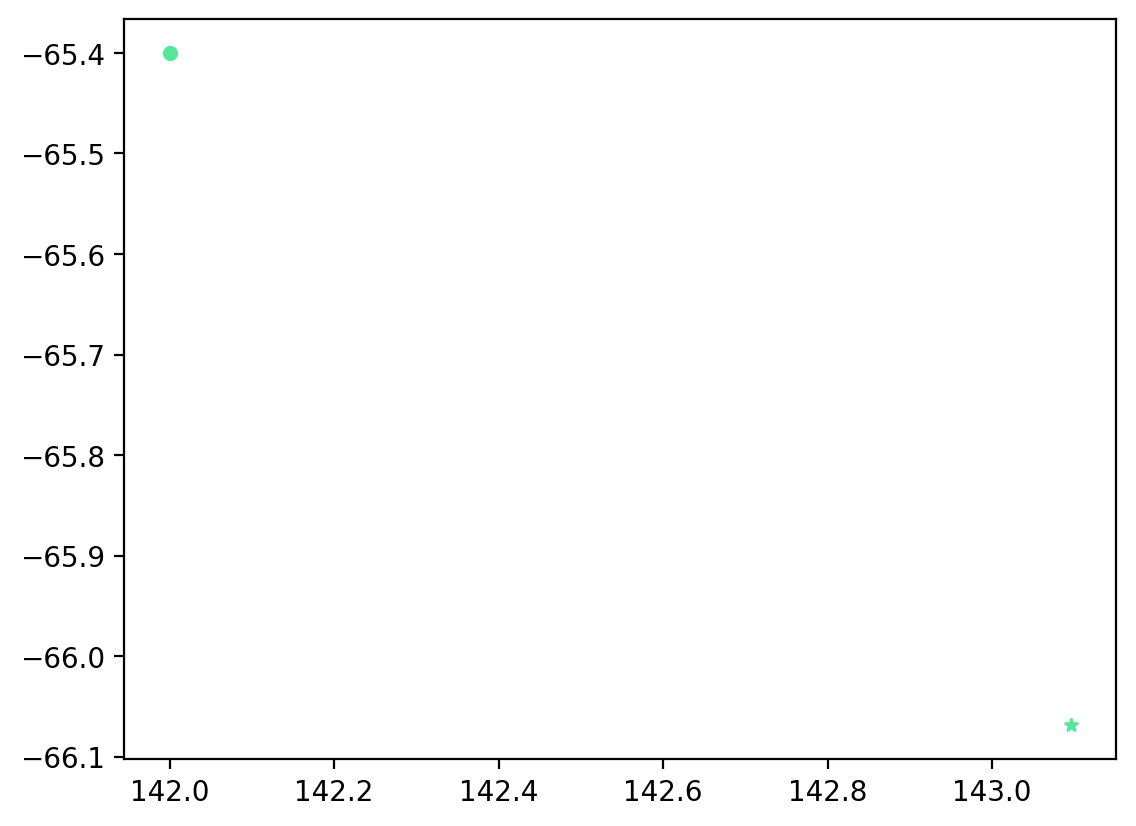

In [79]:
mertz_moved2 = [142-360, -65.4]
plt.scatter(np.array(mertz_lon).mean(), np.array(mertz_lat).mean(), s=20, marker='*', color=c_adelie,  zorder=0)
plt.scatter(mertz_moved2[0]+360, mertz_moved2[1], s=20, marker='o', color=c_adelie,  zorder=0)
